# PCam: five normal and five tumor patches (pick for slides)

Loads **PatchCamelyon** training split, samples **5** label-0 (no metastasis in center / “normal” for the task) and **5** label-1 (“tumor”) patches with **global train indices** shown on each panel.

**Requirements:** `pcam_data` with PCam HDF5 files — either `training/camelyonpatch_level_2_split_train_{x,y}.h5` or the same filenames **flat** under `pcam_data/`. Adjust `DATA_DIR` or `SEED` in the next cell if needed.

Label convention: **0 = negative (normal)**, **1 = positive (tumor)** (PCam benchmark).

In [3]:
import os
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
SEED = 12345  # change to sample a different quintuple (e.g. 42 was an earlier group)
N_EACH = 5

# Organized layout: pcam_data/training/*.h5 — or flat: pcam_data/*.h5
_organized_x = os.path.join(
    DATA_DIR, "training", "camelyonpatch_level_2_split_train_x.h5"
)
_flat_x = os.path.join(DATA_DIR, "camelyonpatch_level_2_split_train_x.h5")
if os.path.isfile(_organized_x):
    train_x_path = _organized_x
    train_y_path = os.path.join(
        DATA_DIR, "training", "camelyonpatch_level_2_split_train_y.h5"
    )
elif os.path.isfile(_flat_x):
    train_x_path = _flat_x
    train_y_path = os.path.join(DATA_DIR, "camelyonpatch_level_2_split_train_y.h5")
else:
    raise FileNotFoundError(
        f"PCam train HDF5 not found under {DATA_DIR}. "
        "Expected training/camelyonpatch_level_2_split_train_x.h5 or flat camelyonpatch_level_2_split_train_x.h5."
    )

with h5py.File(train_y_path, "r") as f:
    y_all = np.asarray(f["y"]).reshape(-1)

idx_normal_pool = np.where(y_all == 0)[0]
idx_tumor_pool = np.where(y_all == 1)[0]

rng = np.random.default_rng(SEED)
idx_normal = rng.choice(idx_normal_pool, size=N_EACH, replace=False)
idx_tumor = rng.choice(idx_tumor_pool, size=N_EACH, replace=False)

idx_normal.sort()
idx_tumor.sort()

print("Normal (y=0) train indices:", idx_normal.tolist())
print("Tumor (y=1) train indices:", idx_tumor.tolist())

Normal (y=0) train indices: [53556, 59555, 83130, 183419, 206726]
Tumor (y=1) train indices: [87283, 102478, 148745, 156880, 220061]


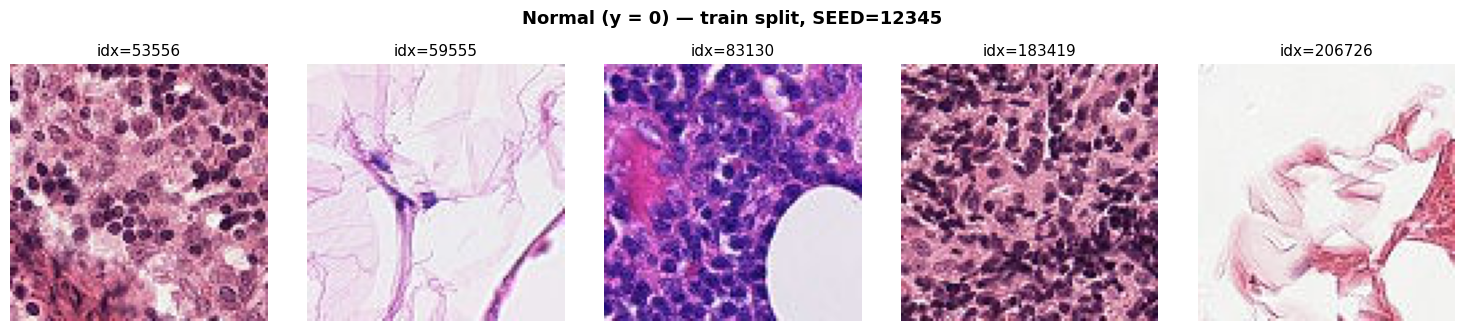

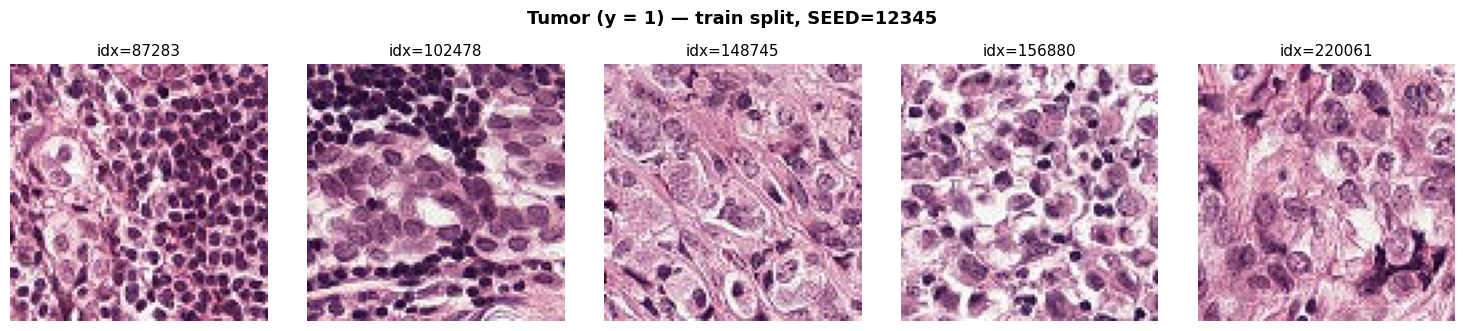

In [4]:
def load_patch_rgb(idx: int) -> np.ndarray:
    with h5py.File(train_x_path, "r") as fx:
        x = np.asarray(fx["x"][idx], dtype=np.float32)
    if x.ndim == 3 and x.shape[0] in (1, 3) and x.shape[-1] not in (1, 3, 4):
        x = np.transpose(x, (1, 2, 0))
    if x.max() <= 1.0:
        x = (np.clip(x, 0, 1) * 255).astype(np.uint8)
    else:
        x = np.clip(x, 0, 255).astype(np.uint8)
    return x


def plot_row(indices, title, suptitle_suffix=""):
    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3.2))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(load_patch_rgb(int(idx)))
        ax.set_title(f"idx={int(idx)}", fontsize=11)
        ax.axis("off")
    fig.suptitle(title + suptitle_suffix, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_row(idx_normal, "Normal (y = 0)", f" — train split, SEED={SEED}")
plot_row(idx_tumor, "Tumor (y = 1)", f" — train split, SEED={SEED}")

**Tip:** Change `SEED` and re-run all cells to get a new random set of five per class (default is now `12345`; try `42`, `999`, …). For slides, note the printed `idx=…` values so you can reload the same patch later with `load_patch_rgb(that_idx)`.